# Business Sales Performance Analytics

## Future Interns – Data Science & Analytics Task 1

### Project Overview

This project analyzes business sales data to understand sales performance, profitability, product performance, category performance, regional trends, and the impact of discounts on profitability.

The objective is to identify important business trends and provide data-driven recommendations that can help improve sales and profitability.

### Business Questions

- Which products generate the highest sales and profit?
- How do sales change over time?
- Which categories perform best?
- Which regions generate the most sales and profit?
- How do discounts affect profitability?
- Which products and sub-categories are loss-making?
- What actions can the business take to improve performance?

### Tools Used

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib

### Analysis Areas

1. Data Cleaning and Preparation
2. Business KPI Analysis
3. Sales Trend Analysis
4. Product Performance Analysis
5. Category Analysis
6. Regional Analysis
7. Discount and Profitability Analysis
8. Loss-Making Product Analysis
9. Business Insights and Recommendations

## 1. Data Cleaning and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [4]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [5]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [6]:
print("Negative Sales:", (df['Sales'] < 0).sum())
print("Negative Quantity:", (df['Quantity'] < 0).sum())
print("Negative Discount:", (df['Discount'] < 0).sum())

Negative Sales: 0
Negative Quantity: 0
Negative Discount: 0


In [7]:
print("Start Date:", df['Order Date'].min())
print("End Date:", df['Order Date'].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows:
0

Data Types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [11]:
print("Categories:")
print(df['Category'].unique())

print("\nSub-Categories:")
print(df['Sub-Category'].unique())

print("\nRegions:")
print(df['Region'].unique())

print("\nSegments:")
print(df['Segment'].unique())

print("\nShip Modes:")
print(df['Ship Mode'].unique())

Categories:
<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Sub-Categories:
<StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str

Regions:
<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Segments:
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

Ship Modes:
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str


In [12]:
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())
print("Total Products:", df['Product ID'].nunique())
print("Total Categories:", df['Category'].nunique())
print("Total Regions:", df['Region'].nunique())

Total Orders: 5009
Total Customers: 793
Total Products: 1862
Total Categories: 3
Total Regions: 4


## 2. Business KPI Analysis

In [13]:
# Business KPIs

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity Sold: 37873
Total Orders: 5009
Total Customers: 793
Average Order Value: 458.61
Profit Margin: 12.47 %


## 3. Sales Trend Analysis

In [14]:
# Yearly Sales Analysis

yearly_sales = df.groupby(
    df['Order Date'].dt.year
)['Sales'].sum()

print(yearly_sales)

Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


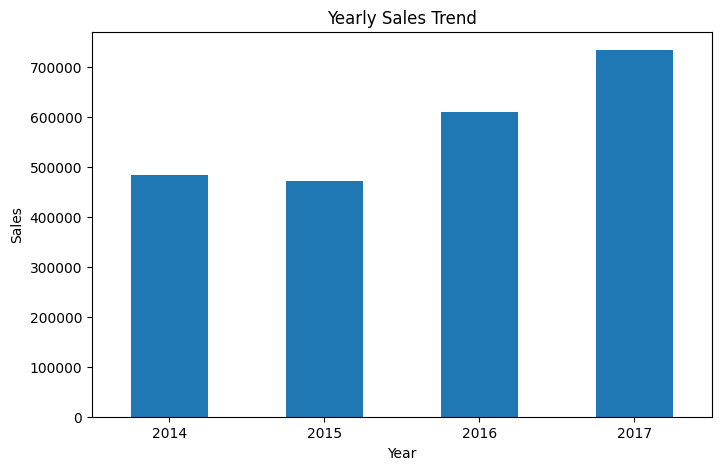

In [15]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='bar')

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

In [16]:
yearly_profit = df.groupby(
    df['Order Date'].dt.year
)['Profit'].sum()

print(yearly_profit)

Order Date
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


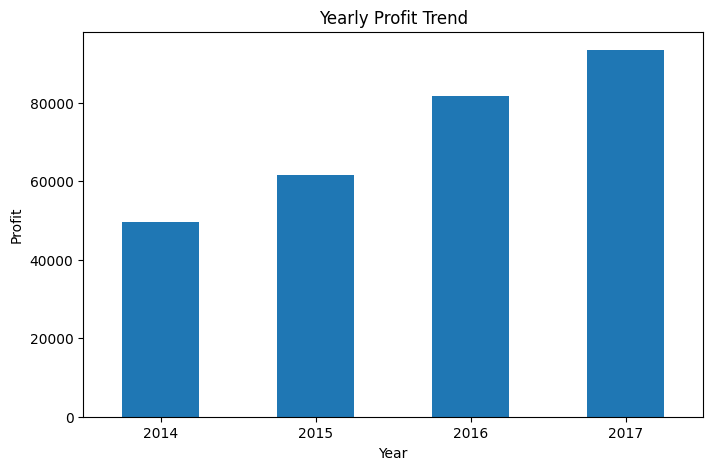

In [17]:
plt.figure(figsize=(8, 5))

yearly_profit.plot(kind='bar')

plt.title('Yearly Profit Trend')
plt.xlabel('Year')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.show()

In [18]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

print(monthly_sales)

Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


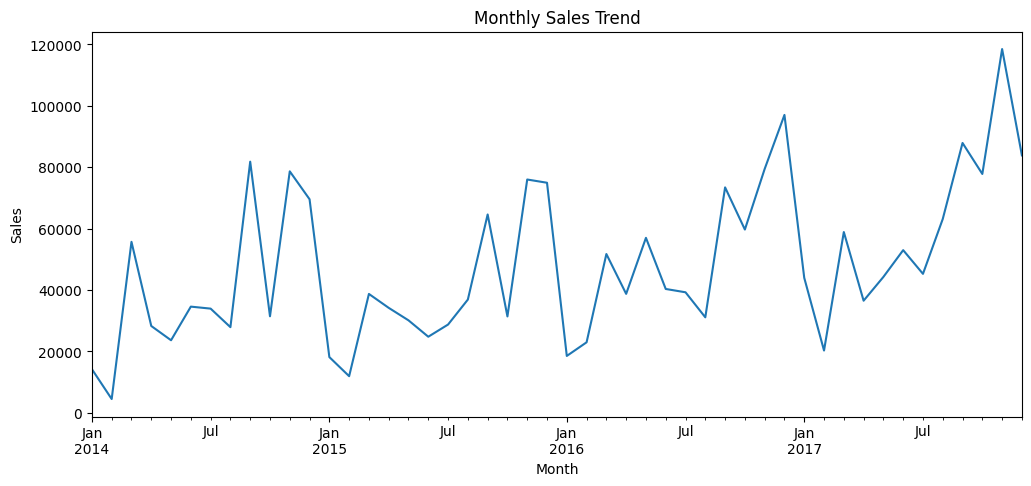

In [19]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

In [20]:
# Year-over-Year Sales Growth

yearly_sales_growth = yearly_sales.pct_change() * 100

print(yearly_sales_growth.round(2))

Order Date
2014      NaN
2015    -2.83
2016    29.47
2017    20.36
Name: Sales, dtype: float64


In [21]:
yearly_analysis = pd.DataFrame({
    'Sales': yearly_sales,
    'Profit': yearly_profit,
    'Sales Growth %': yearly_sales_growth
})

yearly_analysis.round(2)

,Sales,Profit,Sales Growth %
Order Date,,,
2014,484247.50,49543.97,NaN
2015,470532.51,61618.60,-2.83
2016,609205.60,81795.17,29.47
2017,733215.26,93439.27,20.36


In [22]:
highest_sales_month = monthly_sales.idxmax()
highest_sales_value = monthly_sales.max()

print("Highest Sales Month:", highest_sales_month)
print("Highest Monthly Sales:", round(highest_sales_value, 2))

Highest Sales Month: 2017-11
Highest Monthly Sales: 118447.82


In [23]:
lowest_sales_month = monthly_sales.idxmin()
lowest_sales_value = monthly_sales.min()

print("Lowest Sales Month:", lowest_sales_month)
print("Lowest Monthly Sales:", round(lowest_sales_value, 2))

Lowest Sales Month: 2014-02
Lowest Monthly Sales: 4519.89


## 4. Product Performance Analysis

In [24]:
# STEP 13.1 - Top 10 Products by Sales

top_products_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

print("Top 10 Products by Sales:")
print(top_products_sales.head(10).round(2))

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.69
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.90
GBC DocuBind P400 Electric Binding System                                      17965.07
High Speed Automatic Electric Letter Opener                                    17030.31
Name: Sales, dtype: float64


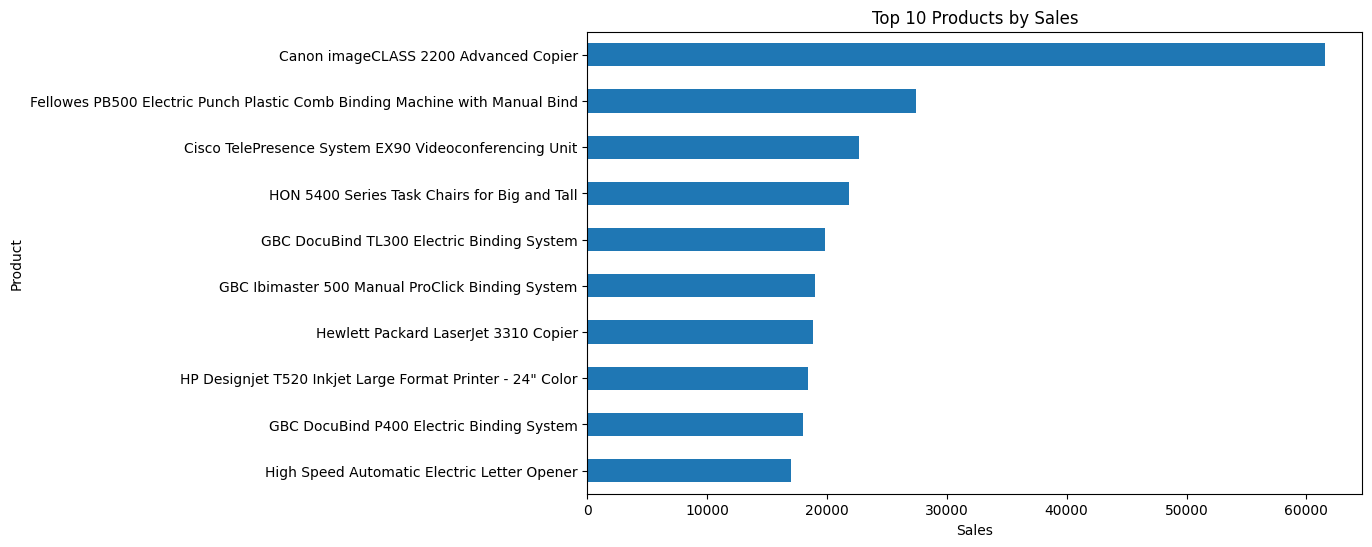

In [25]:
# Top 10 Products by Sales - Bar Chart

top_10_sales = top_products_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_10_sales.plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

plt.show()

In [26]:
# STEP 13.3 - Top 10 Products by Profit

top_products_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

print("Top 10 Products by Profit:")
print(top_products_profit.head(10).round(2))

Top 10 Products by Profit:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.04
Hewlett Packard LaserJet 3310 Copier                                            6983.88
Canon PC1060 Personal Laser Copier                                              4570.93
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.98
Ativa V4110MDD Micro-Cut Shredder                                               3772.95
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.97
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.28
Ibico EPK-21 Electric Binding System                                            3345.28
Zebra ZM400 Thermal Label Printer                                               3343.54
Name: Profit, dtype: float64


In [27]:
# STEP 13.4 - Compare Top Sales Products with Profit

top_products_comparison = pd.DataFrame({
    'Sales': top_products_sales,
    'Profit': top_products_profit
})

top_products_comparison = top_products_comparison.loc[
    top_products_sales.head(10).index
]

top_products_comparison.round(2)

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08
HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00
GBC DocuBind TL300 Electric Binding System,19823.48,2233.51
GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17


## 5. Category Analysis

In [28]:
# STEP 14.1 - Sales by Category

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("Sales by Category:")
print(category_sales.round(2))

Sales by Category:
Category
Technology         836154.03
Furniture          741999.80
Office Supplies    719047.03
Name: Sales, dtype: float64


In [29]:
# STEP 14.2 - Profit by Category

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print("Profit by Category:")
print(category_profit.round(2))

Profit by Category:
Category
Technology         145454.95
Office Supplies    122490.80
Furniture           18451.27
Name: Profit, dtype: float64


In [30]:
# STEP 14.3 - Quantity Sold by Category

category_quantity = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

print("Quantity Sold by Category:")
print(category_quantity)

Quantity Sold by Category:
Category
Office Supplies    22906
Furniture           8028
Technology          6939
Name: Quantity, dtype: int64


In [31]:
# STEP 14.4 - Category Performance Summary

category_analysis = pd.DataFrame({
    'Sales': category_sales,
    'Profit': category_profit,
    'Quantity': category_quantity
})

category_analysis['Profit Margin %'] = (
    category_analysis['Profit'] / category_analysis['Sales']
) * 100

category_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Category,,,,
Furniture,741999.80,18451.27,8028,2.49
Office Supplies,719047.03,122490.80,22906,17.04
Technology,836154.03,145454.95,6939,17.40


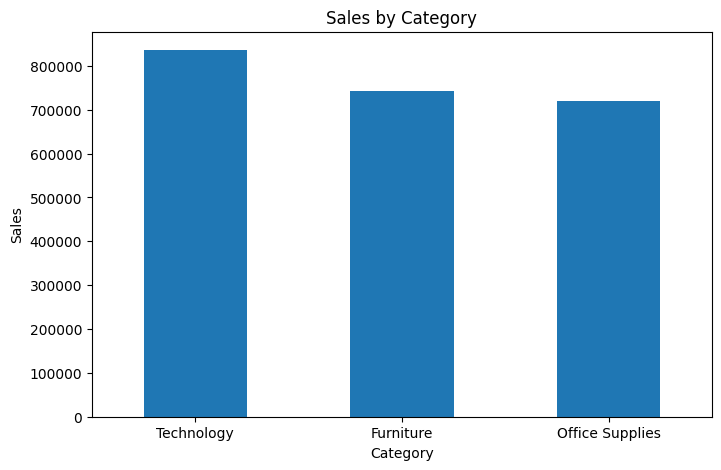

In [32]:
# Sales by Category

plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

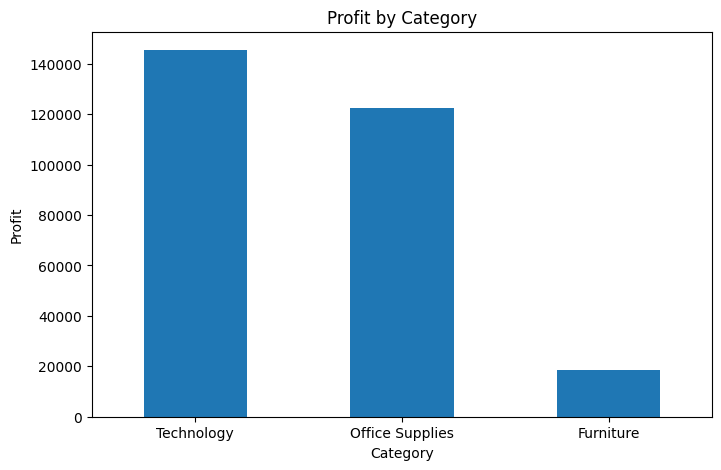

In [33]:
# Profit by Category

plt.figure(figsize=(8, 5))

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.show()

## 6. Regional Analysis

In [34]:
# STEP 15.1 - Sales by Region

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("Sales by Region:")
print(region_sales.round(2))

Sales by Region:
Region
West       725457.82
East       678781.24
Central    501239.89
South      391721.90
Name: Sales, dtype: float64


In [35]:
# STEP 15.2 - Profit by Region

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print("Profit by Region:")
print(region_profit.round(2))

Profit by Region:
Region
West       108418.45
East        91522.78
South       46749.43
Central     39706.36
Name: Profit, dtype: float64


In [36]:
# STEP 15.3 - Quantity Sold by Region

region_quantity = df.groupby('Region')['Quantity'].sum().sort_values(ascending=False)

print("Quantity Sold by Region:")
print(region_quantity)

Quantity Sold by Region:
Region
West       12266
East       10618
Central     8780
South       6209
Name: Quantity, dtype: int64


In [37]:
# STEP 15.4 - Regional Performance Summary

region_analysis = pd.DataFrame({
    'Sales': region_sales,
    'Profit': region_profit,
    'Quantity': region_quantity
})

region_analysis['Profit Margin %'] = (
    region_analysis['Profit'] / region_analysis['Sales']
) * 100

region_analysis.round(2)

,Sales,Profit,Quantity,Profit Margin %
Region,,,,
Central,501239.89,39706.36,8780,7.92
East,678781.24,91522.78,10618,13.48
South,391721.90,46749.43,6209,11.93
West,725457.82,108418.45,12266,14.94


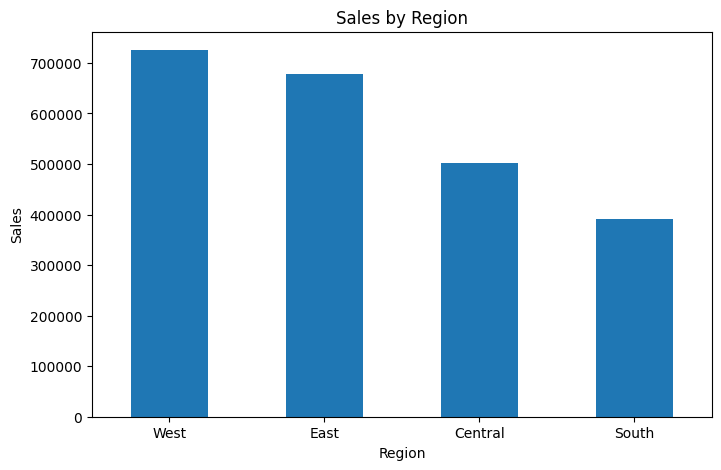

In [38]:
# Sales by Region

plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

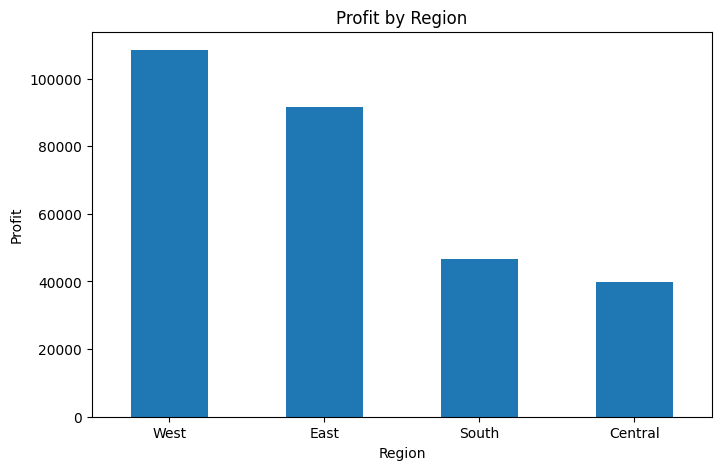

In [39]:
# Profit by Region

plt.figure(figsize=(8, 5))

region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.show()

In [40]:
# STEP 16.1 - Sales by Sub-Category

subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print("Sales by Sub-Category:")
print(subcategory_sales.round(2))

Sales by Sub-Category:
Sub-Category
Phones         330007.05
Chairs         328449.10
Storage        223843.61
Tables         206965.53
Binders        203412.73
Machines       189238.63
Accessories    167380.32
Copiers        149528.03
Bookcases      114880.00
Appliances     107532.16
Furnishings     91705.16
Paper           78479.21
Supplies        46673.54
Art             27118.79
Envelopes       16476.40
Labels          12486.31
Fasteners        3024.28
Name: Sales, dtype: float64


In [41]:
# STEP 16.2 - Profit by Sub-Category

subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

print("Profit by Sub-Category:")
print(subcategory_profit.round(2))

Profit by Sub-Category:
Sub-Category
Copiers        55617.82
Phones         44515.73
Accessories    41936.64
Paper          34053.57
Binders        30221.76
Chairs         26590.17
Storage        21278.83
Appliances     18138.01
Furnishings    13059.14
Envelopes       6964.18
Art             6527.79
Labels          5546.25
Machines        3384.76
Fasteners        949.52
Supplies       -1189.10
Bookcases      -3472.56
Tables        -17725.48
Name: Profit, dtype: float64


In [42]:
# STEP 16.3 - Sub-Category Performance

subcategory_analysis = pd.DataFrame({
    'Sales': subcategory_sales,
    'Profit': subcategory_profit
})

subcategory_analysis['Profit Margin %'] = (
    subcategory_analysis['Profit'] /
    subcategory_analysis['Sales']
) * 100

subcategory_analysis.round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Accessories,167380.32,41936.64,25.05
Appliances,107532.16,18138.01,16.87
Art,27118.79,6527.79,24.07
Binders,203412.73,30221.76,14.86
Bookcases,114880.00,-3472.56,-3.02
Chairs,328449.10,26590.17,8.10
Copiers,149528.03,55617.82,37.20
Envelopes,16476.40,6964.18,42.27
Fasteners,3024.28,949.52,31.40


In [43]:
# STEP 16.4 - Lowest Profit Sub-Categories

worst_subcategories = subcategory_analysis.sort_values(
    'Profit'
).head(10)

worst_subcategories.round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Tables,206965.53,-17725.48,-8.56
Bookcases,114880.00,-3472.56,-3.02
Supplies,46673.54,-1189.10,-2.55
Fasteners,3024.28,949.52,31.40
Machines,189238.63,3384.76,1.79
Labels,12486.31,5546.25,44.42
Art,27118.79,6527.79,24.07
Envelopes,16476.40,6964.18,42.27
Furnishings,91705.16,13059.14,14.24


In [44]:
# STEP 16.5 - Highest Profit Sub-Categories

best_subcategories = subcategory_analysis.sort_values(
    'Profit',
    ascending=False
).head(10)

best_subcategories.round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Copiers,149528.03,55617.82,37.20
Phones,330007.05,44515.73,13.49
Accessories,167380.32,41936.64,25.05
Paper,78479.21,34053.57,43.39
Binders,203412.73,30221.76,14.86
Chairs,328449.10,26590.17,8.10
Storage,223843.61,21278.83,9.51
Appliances,107532.16,18138.01,16.87
Furnishings,91705.16,13059.14,14.24


## 7. Discount and Profitability Analysis

In [50]:
# STEP 17.1 - Average Discount by Category

category_discount = df.groupby('Category')['Discount'].mean().sort_values(ascending=False)

print("Average Discount by Category:")
print((category_discount * 100).round(2))

Average Discount by Category:
Category
Furniture          17.39
Office Supplies    15.73
Technology         13.23
Name: Discount, dtype: float64


In [51]:
# STEP 17.2 - Average Discount by Sub-Category

subcategory_discount = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)

print("Average Discount by Sub-Category:")
print((subcategory_discount * 100).round(2))

Average Discount by Sub-Category:
Sub-Category
Binders        37.23
Machines       30.61
Tables         26.13
Bookcases      21.11
Chairs         17.02
Appliances     16.65
Copiers        16.18
Phones         15.46
Furnishings    13.83
Fasteners       8.20
Envelopes       8.03
Accessories     7.85
Supplies        7.68
Paper           7.49
Art             7.49
Storage         7.47
Labels          6.87
Name: Discount, dtype: float64


In [52]:
# STEP 17.3 - Discount vs Profit

discount_profit = df.groupby('Discount').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
})

discount_profit['Profit Margin %'] = (
    discount_profit['Profit'] /
    discount_profit['Sales']
) * 100

discount_profit.round(2)

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.00,1087908.47,320987.60,18267,29.51
0.10,54369.35,9029.18,373,16.61
0.15,27558.52,1418.99,198,5.15
0.20,764594.37,90337.31,13660,11.82
0.30,103226.66,-10369.28,849,-10.05
0.32,14493.46,-2391.14,105,-16.50
0.40,116417.78,-23057.05,786,-19.81
0.45,5484.97,-2493.11,45,-45.45
0.50,58918.54,-20506.43,241,-34.80


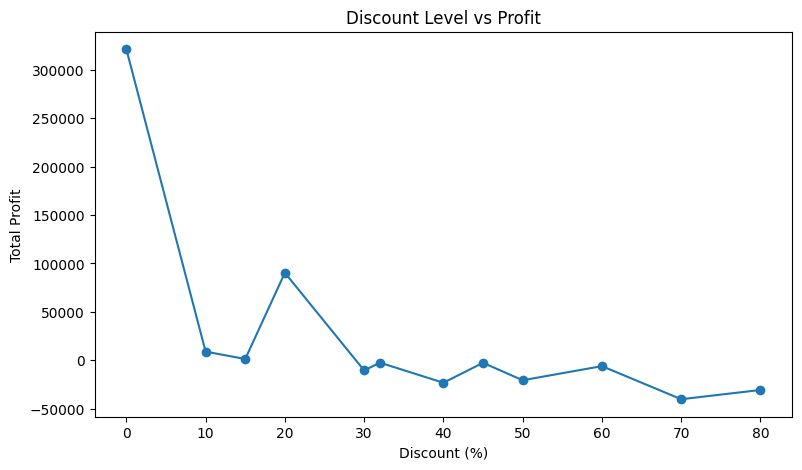

In [53]:
# STEP 17.4 - Discount vs Profit

plt.figure(figsize=(9, 5))

plt.plot(
    discount_profit.index * 100,
    discount_profit['Profit'],
    marker='o'
)

plt.title('Discount Level vs Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Total Profit')

plt.show()

## 8. Loss-Making Product Analysis

In [54]:
# STEP 18.1 - Loss-Making Products

product_analysis = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
})

product_analysis['Profit Margin %'] = (
    product_analysis['Profit'] /
    product_analysis['Sales']
) * 100

loss_making_products = product_analysis[
    product_analysis['Profit'] < 0
].sort_values('Profit')

loss_making_products.head(10).round(2)

,Sales,Profit,Quantity,Discount,Profit Margin %
Product Name,,,,,
Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97,9,0.53,-80.00
Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18,0.40,-27.27
Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4,0.50,-48.00
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.64,-2876.12,27,0.28,-29.00
Bush Advantage Collection Racetrack Conference Table,9544.72,-1934.40,33,0.35,-20.27
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27,0.45,-10.45
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6,0.50,-8.00
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18,22,0.10,-7.80
Balt Solid Wood Round Tables,6518.75,-1201.06,19,0.20,-18.42


In [55]:
# STEP 18.2 - Number of Loss-Making Products

print(
    "Number of Loss-Making Products:",
    (product_analysis['Profit'] < 0).sum()
)

Number of Loss-Making Products: 301


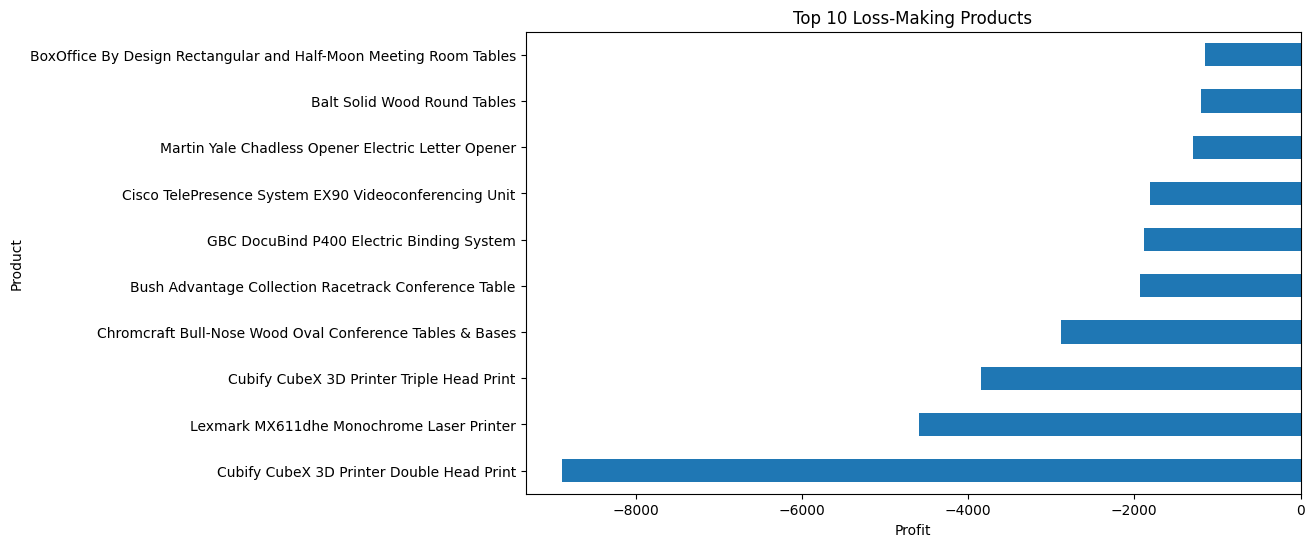

In [56]:
# STEP 18.3 - Top 10 Loss-Making Products

top_losses = loss_making_products.head(10)['Profit'].sort_values()

plt.figure(figsize=(10, 6))

top_losses.plot(kind='barh')

plt.title('Top 10 Loss-Making Products')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.show()

In [57]:
# STEP 19.1 - Profit by Sub-Category

subcategory_analysis = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
})

subcategory_analysis['Profit Margin %'] = (
    subcategory_analysis['Profit'] /
    subcategory_analysis['Sales']
) * 100

subcategory_analysis = subcategory_analysis.sort_values(
    'Profit',
    ascending=False
)

subcategory_analysis.round(2)

,Sales,Profit,Quantity,Discount,Profit Margin %
Sub-Category,,,,,
Copiers,149528.03,55617.82,234,0.16,37.20
Phones,330007.05,44515.73,3289,0.15,13.49
Accessories,167380.32,41936.64,2976,0.08,25.05
Paper,78479.21,34053.57,5178,0.07,43.39
Binders,203412.73,30221.76,5974,0.37,14.86
Chairs,328449.10,26590.17,2356,0.17,8.10
Storage,223843.61,21278.83,3158,0.07,9.51
Appliances,107532.16,18138.01,1729,0.17,16.87
Furnishings,91705.16,13059.14,3563,0.14,14.24


In [58]:
# STEP 19.2 - Top 5 Profitable Sub-Categories

print("Top 5 Profitable Sub-Categories:")

print(
    subcategory_analysis.head(5).round(2)
)

Top 5 Profitable Sub-Categories:
                  Sales    Profit  Quantity  Discount  Profit Margin %
Sub-Category                                                          
Copiers       149528.03  55617.82       234      0.16            37.20
Phones        330007.05  44515.73      3289      0.15            13.49
Accessories   167380.32  41936.64      2976      0.08            25.05
Paper          78479.21  34053.57      5178      0.07            43.39
Binders       203412.73  30221.76      5974      0.37            14.86


In [59]:
# STEP 19.3 - Bottom 5 Sub-Categories

print("Bottom 5 Sub-Categories:")

print(
    subcategory_analysis.tail(5).round(2)
)

Bottom 5 Sub-Categories:
                  Sales    Profit  Quantity  Discount  Profit Margin %
Sub-Category                                                          
Machines      189238.63   3384.76       440      0.31             1.79
Fasteners       3024.28    949.52       914      0.08            31.40
Supplies       46673.54  -1189.10       647      0.08            -2.55
Bookcases     114880.00  -3472.56       868      0.21            -3.02
Tables        206965.53 -17725.48      1241      0.26            -8.56


## 9. Business Insights and Recommendations

In [60]:
# STEP 20 - Key Business Insights

key_insights = {
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Profit Margin',
        'Total Orders',
        'Total Customers',
        'Best Sales Region',
        'Best Profit Region',
        'Best Sales Category',
        'Best Profit Category',
        'Highest Sales Month',
        'Loss-Making Products'
    ],
    
    'Value': [
        round(total_sales, 2),
        round(total_profit, 2),
        round(profit_margin, 2),
        total_orders,
        total_customers,
        region_sales.idxmax(),
        region_profit.idxmax(),
        category_sales.idxmax(),
        category_profit.idxmax(),
        highest_sales_month,
        len(loss_making_products)
    ]
}

key_insights_df = pd.DataFrame(key_insights)

key_insights_df

,Metric,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Profit Margin,12.47
3,Total Orders,5009
4,Total Customers,793
5,Best Sales Region,West
6,Best Profit Region,West
7,Best Sales Category,Technology
8,Best Profit Category,Technology
9,Highest Sales Month,2017-11


In [61]:
# STEP 21 - Business Insights and Recommendations

print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print("\n1. Overall Performance")
print(f"The business generated total sales of {total_sales:,.2f} "
      f"with a total profit of {total_profit:,.2f}.")
print(f"The overall profit margin was {profit_margin:.2f}%.")

print("\n2. Regional Performance")
print(f"The West region generated the highest sales of "
      f"{region_sales['West']:,.2f}.")
print(f"The West region also generated the highest profit of "
      f"{region_profit['West']:,.2f}.")

print("\n3. Category Performance")
print(f"Technology was the highest-performing category by sales "
      f"with {category_sales['Technology']:,.2f}.")
print(f"Technology also generated the highest profit of "
      f"{category_profit['Technology']:,.2f}.")

print("\n4. Product Performance")
print("The Canon imageCLASS 2200 Advanced Copier was the "
      "top-selling product by revenue.")
print("However, some high-sales products generated negative profit.")

print("\n5. Discount Impact")
print("Higher discount levels were generally associated with "
      "lower or negative profitability.")
print("The business should carefully control discounts on low-margin products.")

print("\n6. Loss-Making Products")
print(f"There are {len(loss_making_products)} products generating negative profit.")
print("These products should be reviewed for pricing, discounting, "
      "cost, or demand issues.")

print("\n7. Business Recommendations")
print("- Focus on Technology products because they generate strong sales and profit.")
print("- Continue investing in the West region while improving weaker regions.")
print("- Review loss-making products and consider price or cost adjustments.")
print("- Reduce excessive discounts, especially on products with low profit margins.")
print("- Analyze high-sales but low-profit products separately before increasing their sales.")

KEY BUSINESS INSIGHTS

1. Overall Performance
The business generated total sales of 2,297,200.86 with a total profit of 286,397.02.
The overall profit margin was 12.47%.

2. Regional Performance
The West region generated the highest sales of 725,457.82.
The West region also generated the highest profit of 108,418.45.

3. Category Performance
Technology was the highest-performing category by sales with 836,154.03.
Technology also generated the highest profit of 145,454.95.

4. Product Performance
The Canon imageCLASS 2200 Advanced Copier was the top-selling product by revenue.
However, some high-sales products generated negative profit.

5. Discount Impact
Higher discount levels were generally associated with lower or negative profitability.
The business should carefully control discounts on low-margin products.

6. Loss-Making Products
There are 301 products generating negative profit.
These products should be reviewed for pricing, discounting, cost, or demand issues.

7. Business Reco

## 10. Conclusion

This analysis provides a clear view of the company's sales and profitability performance.

The business generated strong overall sales, with Technology being the best-performing category and the West region leading in both sales and profit. However, Furniture showed relatively low profitability, while several products generated losses.

The analysis also shows that higher discount levels are associated with lower profitability in the dataset. Therefore, improving pricing strategies, controlling excessive discounts, and reviewing loss-making products can help improve overall business profitability.